# 05 — Heterogeneity Analysis: SHAP on the X-Learner's Predicted Uplift

Explains the model `04_evaluation.ipynb` carried forward for Womens E-Mail (X-Learner GBM).
Mens excluded: Qini AUC CI includes zero in `04`, so there's no ranking worth explaining.

In [1]:
%pip install pandas numpy scikit-learn scikit-uplift pyarrow shap matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 1.5 MB/s  0:00:38ta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 1.3 MB/s  0:00:02m1.3 MB/s eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]━━━━━━━ 4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

from src.models import (
    XLearner,
    build_gradient_boosting_base_learner,
    build_gradient_boosting_effect_regressor,
    compute_xlearner_uplift_shap,
    prepare_arm_splits,
)

pd.set_option("display.max_columns", None)

with open("../data/processed/feature_manifest.json") as f:
    manifest = json.load(f)

feature_columns = manifest["feature_columns"]

train_df = pd.read_parquet("../data/processed/train.parquet")
val_df = pd.read_parquet("../data/processed/val.parquet")
test_df = pd.read_parquet("../data/processed/test.parquet")

print(f"train: {train_df.shape}, val: {val_df.shape}, test: {test_df.shape}")
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")

train: (38400, 13), val: (12800, 13), test: (12800, 13)
Feature columns (9): ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']


## Step 0: Model and arm

| Arm | Selected model | Qini AUC (95% CI) | Reliable? |
|---|---|---|---|
| Mens E-Mail | S-Learner (GBM) | 0.012 ([-0.021, 0.048]) | No — CI includes zero |
| Womens E-Mail | X-Learner (GBM) | 0.076 ([0.042, 0.111]) | Yes — CI excludes zero |

X-Learner used here because it's the model `04` carries into the business-impact tables,
not because it beats S-Learner (0.072, nearly identical CI — statistically tied). Extra
reason for this notebook: its second stage already models the effect directly, so the SHAP
decomposition is exact rather than a difference between two explanations (see Step 2).

Mens excluded entirely: every model's CI includes zero, so the ranking is indistinguishable
from random. A beeswarm on that model would be explaining noise.

## Step 1: Refit X-Learner (GBM), Womens

No persisted model from `02`–`04`, so refitting here too, with the same hyperparameters
`04` Step 1 found: `{'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 150,
'min_samples_leaf': 100}`. Fit on train+val (n=34,155), explained on test (n=8,538).
Predicted uplift on test ranges from -0.043 to 0.116, mean 0.044.

In [3]:
womens_splits = prepare_arm_splits(
    train_df, val_df, test_df,
    treatment_group="Womens E-Mail",
    feature_columns=feature_columns,
    outcome_col="visit",
)


X_train_womens = pd.concat([womens_splits["train"][0], womens_splits["val"][0]], ignore_index=True)
y_train_womens = pd.concat([womens_splits["train"][1], womens_splits["val"][1]], ignore_index=True)
treat_train_womens = pd.concat([womens_splits["train"][2], womens_splits["val"][2]], ignore_index=True)
X_test_womens, y_test_womens, treat_test_womens = womens_splits["test"]
X_test_womens = X_test_womens.reset_index(drop=True)

# Reused verbatim from 04_evaluation.ipynb Step 1 (see markdown above) — not re-tuned here.
gbm_params = {
    "learning_rate": 0.1,
    "max_depth": 3,
    "max_iter": 150,
    "min_samples_leaf": 100,
}

xlearner_womens = XLearner(
    estimator_outcome_treatment=build_gradient_boosting_base_learner(**gbm_params, random_state=42),
    estimator_outcome_control=build_gradient_boosting_base_learner(**gbm_params, random_state=42),
    estimator_effect_treatment=build_gradient_boosting_effect_regressor(**gbm_params, random_state=42),
    estimator_effect_control=build_gradient_boosting_effect_regressor(**gbm_params, random_state=42),
    propensity=None,
)
xlearner_womens.fit(X_train_womens, y_train_womens, treat_train_womens)

test_uplift_predictions = xlearner_womens.predict(X_test_womens)
print(f"Refit on train+val (n={len(X_train_womens)}); explaining predictions on test (n={len(X_test_womens)}).")
print(f"Predicted uplift on test — min: {test_uplift_predictions.min():.4f}, "
      f"max: {test_uplift_predictions.max():.4f}, mean: {test_uplift_predictions.mean():.4f}")

Refit on train+val (n=34155); explaining predictions on test (n=8538).
Predicted uplift on test — min: -0.0426, max: 0.1160, mean: 0.0442


## Step 2: How SHAP applies here

`XLearner.fit` trains four models: two *outcome* models (estimate `P(visit=1)` per arm,
only used to generate imputed effect labels for stage 2) and two *effect* models
(`estimator_effect_treatment/control`, regress the imputed effect on `X`).
`XLearner.predict` only calls the two effect models:

`tau(x) = g(x) * tau_control(x) + (1 - g(x)) * tau_treatment(x)`

with `g(x)` constant (known propensity, randomized experiment). Outcome models never enter
predict's call path, so they're excluded from this analysis.

Both effect models are `HistGradientBoostingRegressor`: `shap.TreeExplainer` gives an exact
per-row, per-feature attribution. Weighting the two SHAP explanations by the same `g(x)` and
summing reconstructs `tau(x)` exactly — confirmed below, max reconstruction error 5.55e-17.

Doesn't generalize to the other meta-learners: S-Learner has no first-class "effect" output
to explain directly; T-Learner's two models each explain `P(visit)|arm`, not the effect.

SHAP computed on `X_test_womens`, held out from fitting.

In [4]:
womens_shap_explanation = compute_xlearner_uplift_shap(xlearner_womens, X_test_womens)

reconstructed = womens_shap_explanation.values.sum(axis=1) + womens_shap_explanation.base_values
max_reconstruction_error = np.max(np.abs(reconstructed - test_uplift_predictions))
print(f"Max |sum(SHAP) + base_value - predicted uplift| across the test set: {max_reconstruction_error:.2e}")
assert max_reconstruction_error < 1e-6, (
    "SHAP decomposition does not reconstruct the model's predicted uplift — "
    "see compute_xlearner_uplift_shap before trusting anything downstream."
)
print("Exact decomposition confirmed: every feature's SHAP contribution sums to the model's own prediction.")

Max |sum(SHAP) + base_value - predicted uplift| across the test set: 5.55e-17
Exact decomposition confirmed: every feature's SHAP contribution sums to the model's own prediction.


## Step 3: Which SHAP plots

1. **Beeswarm** — global importance (mean |SHAP|) and direction together.
2. **Dependence plots, top 3 features**: `womens`, `recency`, `history` (mean |SHAP| =
   0.0222, 0.0048, 0.0040 — an order of magnitude above the rest; `mens` is next at 0.0037).
3. **Two waterfalls**, highest- and lowest-predicted-uplift customer.

Excluded: interaction heatmap (Step 2 already gives an exact attribution), dependence
plots for all 9 features, force plots beyond the two customers.


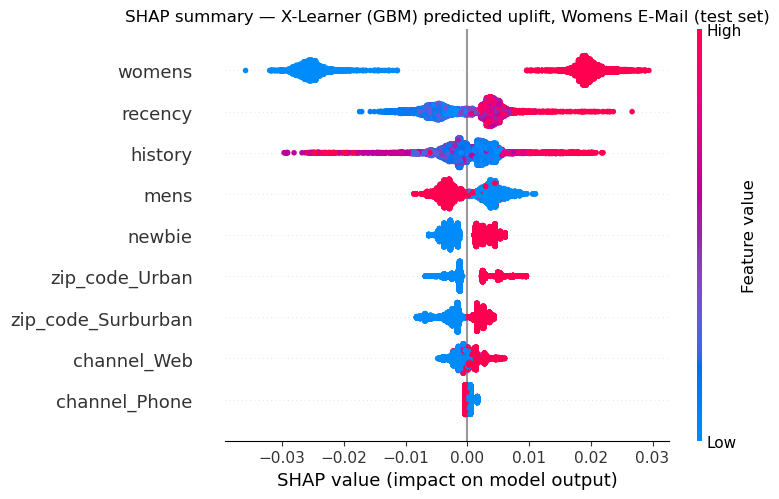

In [5]:
shap.plots.beeswarm(womens_shap_explanation, show=False)
plt.title("SHAP summary — X-Learner (GBM) predicted uplift, Womens E-Mail (test set)")
plt.tight_layout()
plt.show()

Rows ordered by mean |SHAP|; dot color = feature value (red high, blue low), horizontal
position = contribution to that customer's predicted uplift.

`womens` dominates by an order of magnitude and splits cleanly: red (already bought from
the line) adds roughly +0.01 to +0.03, blue subtracts about the same. `recency` and
`history` are smaller and noisier — mixed color bands rather than a clean split, easier to
read off the dependence plots below than the beeswarm alone.

,feature,mean_abs_shap
0,womens,0.022218
1,recency,0.004792
2,history,0.004012
3,mens,0.003665
4,newbie,0.002938
5,zip_code_Urban,0.002934
6,zip_code_Surburban,0.002712
7,channel_Web,0.001313
8,channel_Phone,0.000366


Top 3 features by mean |SHAP| (data-driven, not assumed in advance): ['womens', 'recency', 'history']


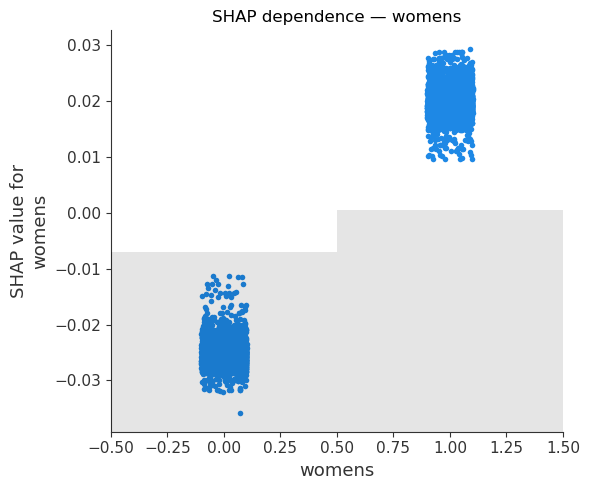

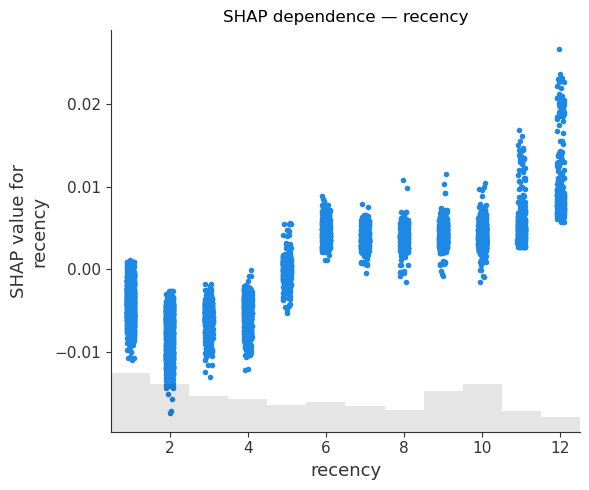

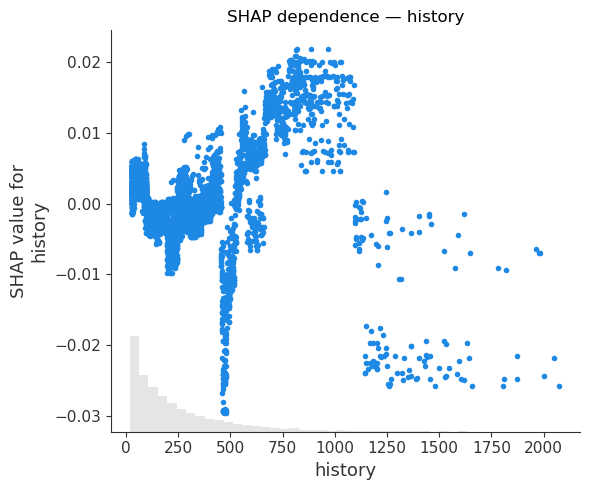

In [6]:
mean_abs_shap = np.abs(womens_shap_explanation.values).mean(axis=0)
importance_df = (
    pd.DataFrame({
        "feature": womens_shap_explanation.feature_names,
        "mean_abs_shap": mean_abs_shap,
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(importance_df)

top_features = importance_df["feature"].head(3).tolist()
print(f"Top 3 features by mean |SHAP| (data-driven, not assumed in advance): {top_features}")

for feature in top_features:
    shap.plots.scatter(womens_shap_explanation[:, feature], show=False)
    plt.title(f"SHAP dependence — {feature}")
    plt.tight_layout()
    plt.show()

X-axis = raw feature value, y-axis = SHAP contribution to predicted uplift.

- `womens`: binary, as expected — two clusters, ~-0.024 for 0 and ~+0.02 for 1. No shape to
  interpret beyond the split itself.
- `recency` (months since last purchase): contribution rises steadily from about -0.01 at
  recency=1 to about +0.02 at recency=12 — the more lapsed the customer, the higher the
  predicted uplift from this campaign. Counter to a naive "recent buyers respond better"
  assumption.
- `history` (past $ spent): rises from ~0 up to roughly $800–1000, peaking around +0.02,
  then drops sharply for a cluster near $500 and turns negative and erratic above ~$1100 —
  but that region has very few customers (thin histogram tail), so the negative tail is a
  handful of points, not a reliable pattern.

## Step 4: Two customers — highest and lowest predicted uplift

The two extremes in the test set: the sharpest contrast between "model is confident this
campaign helps" and the opposite.

Highest predicted-uplift customer (test set):


,recency,history,mens,womens,newbie,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
3122,12,890.77002,1,1,1,1,0,0,0


Predicted uplift: 0.1160


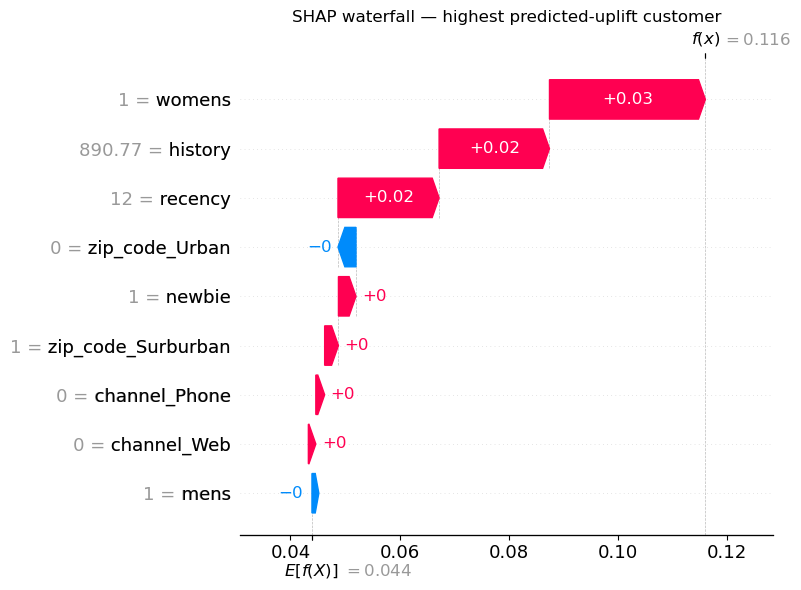

In [7]:
highest_uplift_idx = int(np.argmax(test_uplift_predictions))
lowest_uplift_idx = int(np.argmin(test_uplift_predictions))

print("Highest predicted-uplift customer (test set):")
display(X_test_womens.iloc[[highest_uplift_idx]])
print(f"Predicted uplift: {test_uplift_predictions[highest_uplift_idx]:.4f}")

shap.plots.waterfall(womens_shap_explanation[highest_uplift_idx], show=False)
plt.title("SHAP waterfall — highest predicted-uplift customer")
plt.tight_layout()
plt.show()

Each bar = one feature's contribution, from the base value (0.044) to this customer's
predicted uplift (0.116).

Customer: `womens`=1, `history`=890.77, `recency`=12 — all three top global drivers align
in the same direction: `womens`=1 (+0.03), high `history` (+0.02), `recency`=12 (+0.02),
the three largest bars, matching the top 3 from Step 3. The remaining six features add
under +0.01 combined.

Lowest predicted-uplift customer (test set):


,recency,history,mens,womens,newbie,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
4896,1,475.529999,1,0,0,0,0,1,0


Predicted uplift: -0.0426


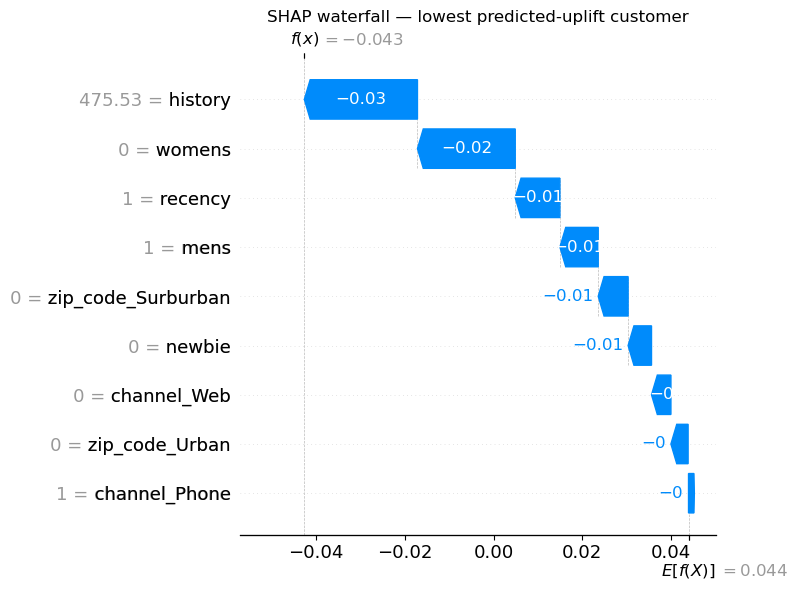

In [8]:
print("Lowest predicted-uplift customer (test set):")
display(X_test_womens.iloc[[lowest_uplift_idx]])
print(f"Predicted uplift: {test_uplift_predictions[lowest_uplift_idx]:.4f}")

shap.plots.waterfall(womens_shap_explanation[lowest_uplift_idx], show=False)
plt.title("SHAP waterfall — lowest predicted-uplift customer")
plt.tight_layout()
plt.show()

Same mechanics, base value 0.044 to this customer's predicted uplift (-0.043).

Customer: `history`=475.53, `womens`=0, `recency`=1, `mens`=1. `history` at 475 sits in the
negative dip from the Step 3 dependence plot (-0.03, the largest bar here) — not a high
value, but the specific range where the dependence plot shows a downward spike. `womens`=0
(-0.02) and `recency`=1 (-0.01, recent purchaser) both pull in the same direction as their
global pattern. All 9 features contribute negatively here — no single offsetting factor.

**Comparing the two.** `womens` and `recency` behave exactly as their global pattern
predicts in both cases: high/1 pushes up, low/0 pushes down. `history` is the exception —
it doesn't act as a simple "higher is better": the high-uplift customer has more history
(890) than the low-uplift one (475), but the low-uplift customer's value falls inside the
negative dip identified in Step 3, not just "low history." The rule for `history` needs
that dip stated explicitly, not just "more spend is better."

## Step 5: Business interpretation

`04` already established that targeting the top 10–30% by predicted uplift beats random at
every budget. Here's why, in the three drivers that account for nearly all of it:

- **Prior womens purchase** is the strongest signal by far: customers who've already bought
  from the womens line show substantially higher predicted uplift than those who haven't.
- **Lapsed customers respond better than recent buyers.** Predicted uplift rises steadily
  with months since last purchase — counter to the intuition that recent, "warm" customers
  are the best target.
- **History has a sweet spot, not a straight line.** Uplift rises with past spend up to
  roughly $800–1000, but a specific mid-range band (around $500) and the small high-spend
  tail (>$1100) both predict *lower* uplift than the trend would suggest.

Targeting rule: within budget, prioritize customers who bought womens items before, are
more lapsed (higher recency), and have moderate-to-high history — while treating very high
history as no guarantee, not an automatic green light. This is a plain-English restatement
of the same ranking behind `04`'s top-10–30% result, not a separate claim.

Caveat: this identifies who the *model* predicts responds better, learned from one
historical experiment — not a causal or behavioral explanation of *why*.

Mens: no targeting recommendation here or anywhere in this notebook — see Step 0.

## Summary

- Explains X-Learner (GBM), Womens E-Mail via an exact SHAP decomposition
  (`compute_xlearner_uplift_shap`, new in `src/models.py`); reconstruction error 5.55e-17.
- Three drivers account for nearly all predicted uplift: prior `womens` purchase (by far
  the largest), `recency` (more lapsed → higher uplift), and `history` (rises up to
  ~$800–1000, then a negative dip around $500 and an erratic, thin-data tail above $1100).
- Mens excluded: no model beats random in `04`, SHAP would be explaining noise.
- Limitations:
  - Only X-Learner explained; S-Learner is statistically tied on Womens (Step 0), a
    parallel SHAP analysis is a reasonable follow-up.
  - The negative dip in `history` around $500 and the tail above $1100 rest on a small
    number of test-set customers — worth flagging to stakeholders as lower-confidence than
    the main upward trend.
  - `g(x)` is constant (known propensity, randomized experiment): all heterogeneity here
    comes from the two effect regressors, not from `g(x)`.